# Part 14 — nnPU follow-up, Zadanie 7: latent geometry

Full geometric battery on canonicalized $u=(z-\beta)/\gamma$, all 10 variants, `test` split.
`part_9` already computed the *within-variant* seed null for `sd_cos_theta`,
`effective_rank`, `participation_ratio`, `two_nn_intrinsic_dimension`, `rsa_spearman_r`,
`procrustes_distance`, `linear_cka`, `knn_overlap` (`seed_null_distribution.csv`) — this
notebook adds what that one did not: the actual *between-variant* signal (pairwise matrix,
with `0004` singled out as the reference per the task spec), `trustworthiness`/`continuity`,
the RSA bce-vs-nnPU direction check, gradient-contribution on `z`, and $\lVert\gamma\rVert$/
$\kappa$ for `0006` vs. `0004`.

**Prediction to check** (stated in the task spec): RSA-Spearman ($\theta$ vs. label-Jaccard
distance) should be *lower* for nnPU variants than for `bce` variants, not higher.

In [1]:
import os
from dataclasses import replace
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.latent import sphere_geometry as geometry
from msi_autoencoder_wrapper.visualization import resolve_theme

2026-08-28 15:21:15,859 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-28 15:21:15,865 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-08-28 15:21:16,989 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-08-28 15:21:16,991 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 22 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-08-28 15:21:16,992 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-08-28 15:21:16,993 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-28 15:21:17,019 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-08-28 15:21:17,241 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 14 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-08-28 15:21:17,243 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 18 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Config

In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"

VARIANT_SPECS = {
    "0000": ("kidney-architecture-predictive__cfg_529dc0e4494b", "grid_0000"),
    "0004": ("kidney-architecture-predictive__cfg_529dc0e4494b", "grid_0004"),
    "0005": ("kidney-architecture-predictive__cfg_529dc0e4494b", "grid_0005"),
    "0006": ("kidney-architecture-predictive__cfg_529dc0e4494b", "grid_0006"),
    "0007": ("kidney-nnpu-objective-controls__cfg_0df14edbfadf", "grid_0000"),
    "0008": ("kidney-nnpu-objective-controls__cfg_0df14edbfadf", "grid_0001"),
    "0009": ("kidney-nnpu-prior-sensitivity__cfg_b89b9dfd127d", "grid_0000"),
    "0010": ("kidney-nnpu-prior-sensitivity__cfg_b89b9dfd127d", "grid_0001"),
    "0011": ("kidney-nnpu-objective-controls__cfg_0df14edbfadf", "grid_0002"),
    "0012": ("kidney-nnpu-objective-controls__cfg_0df14edbfadf", "grid_0003"),
}
NNPU_VARIANTS = {"0006", "0008", "0009", "0010", "0012"}
BCE_VARIANTS = {"0000", "0004", "0005", "0007", "0011"}
REFERENCE_VARIANT = "0004"
REPETITIONS = range(5)
HEAD_NAME = "molecule_primary"
TARGET_FIELD = "molecule"
BATCH_SIZE = 256
PAIR_COUNT = 20000
KNN_K = 10
RANDOM_SEED = 42

RESULTS_DIRECTORY = Path("assets/experiments/08_26/23_08_26_architecture_predictive/nnpu_followup/results")
RESULTS_DIRECTORY.mkdir(parents=True, exist_ok=True)
SEED_NULL_FRAME = pd.read_csv(RESULTS_DIRECTORY / "seed_null_distribution.csv", dtype={"variant": str, "repetition": str})

theme = resolve_theme(None)
theme.apply()
model_colors = {variant: theme.color_for_model(variant, index) for index, variant in enumerate(VARIANT_SPECS)}
theme = replace(theme, model_overrides=model_colors)
theme.apply()

# Verified directly against each variant's config.json (training.parameters.phases[0]
# .criterions) -- not reconstructed from memory. Differences: head loss family (bce vs
# nnpu), whether the bce head is class-balanced (pos_weight) or plain, nnpu's prior
# multiplier, and whether the contractive+InfoNCE(peak_label_invariant) regularizer
# pair (+ its Jaccard negative-weighting variant) is present at all.
VARIANT_DESCRIPTIONS = {
    "0000": "bce (balanced, pos_weight), no regularizers",
    "0004": "bce (balanced, pos_weight), +contractive +peak_label_invariant",
    "0005": "bce (balanced, pos_weight), +contractive +peak_label_invariant +jaccard",
    "0006": "nnpu (prior x1.5), +contractive +peak_label_invariant",
    "0007": "bce (unweighted), +contractive +peak_label_invariant",
    "0008": "nnpu (prior x1.5), +contractive +peak_label_invariant +jaccard",
    "0009": "nnpu (prior x1.0), +contractive +peak_label_invariant",
    "0010": "nnpu (prior x2.0), +contractive +peak_label_invariant",
    "0011": "bce (unweighted), no regularizers",
    "0012": "nnpu (prior x1.5), no regularizers",
}
VARIANT_SHORT_LABELS = {
    "0000": "0000: bce-bal, no-reg",
    "0004": "0004: bce-bal, +reg",
    "0005": "0005: bce-bal, +reg+jac",
    "0006": "0006: nnpu\u00d71.5, +reg",
    "0007": "0007: bce-unw, +reg",
    "0008": "0008: nnpu\u00d71.5, +reg+jac",
    "0009": "0009: nnpu\u00d71.0, +reg",
    "0010": "0010: nnpu\u00d72.0, +reg",
    "0011": "0011: bce-unw, no-reg",
    "0012": "0012: nnpu\u00d71.5, no-reg",
}

## What each variant actually is

### Methodology
#### Theoretical
- Every plot and table below refers to variants only by their 4-digit grid code
  (e.g. `0006`), which by itself says nothing about what that variant actually
  differs by. This table is the single reference point: look here to translate a
  code into its actual settings, instead of cross-referencing `VARIANT_SPECS` and
  three separate campaigns' config files.

#### Implementation
- Built directly from `VARIANT_SPECS` (variant -> campaign/grid_id) and
  `VARIANT_DESCRIPTIONS`, the latter verified against each variant's actual
  `config.json` (`training.parameters.phases[0].criterions`) — not reconstructed
  from memory or notebook comments.

### Notes
- Three independent axes of variation are mixed into these 10 variants: head loss
  family (`bce` vs `nnpu`), whether `bce` is class-balanced (`pos_weight`) or plain,
  and whether the `+contractive +peak_label_invariant` regularizer pair (optionally
  with `+jaccard` negative-weighting) is present at all. `part_13`'s factor
  decomposition isolates these three axes explicitly via paired comparisons and a
  2x2 factorial — this table is just the lookup, not the analysis.


In [3]:
variant_table_rows = [
    {
        "variant": variant, "campaign": campaign_id, "grid_id": grid_id,
        "head_family": "nnpu" if variant in NNPU_VARIANTS else "bce",
        "description": VARIANT_DESCRIPTIONS[variant],
    }
    for variant, (campaign_id, grid_id) in VARIANT_SPECS.items()
]
pd.DataFrame(variant_table_rows).set_index("variant")

,campaign,grid_id,head_family,description
variant,,,,
0000,kidney-architecture-predictive__cfg_529dc0e4494b,grid_0000,bce,"bce (balanced, pos_weight), no regularizers"
0004,kidney-architecture-predictive__cfg_529dc0e4494b,grid_0004,bce,"bce (balanced, pos_weight), +contractive +peak..."
0005,kidney-architecture-predictive__cfg_529dc0e4494b,grid_0005,bce,"bce (balanced, pos_weight), +contractive +peak..."
0006,kidney-architecture-predictive__cfg_529dc0e4494b,grid_0006,nnpu,"nnpu (prior x1.5), +contractive +peak_label_in..."
0007,kidney-nnpu-objective-controls__cfg_0df14edbfadf,grid_0000,bce,"bce (unweighted), +contractive +peak_label_inv..."
0008,kidney-nnpu-objective-controls__cfg_0df14edbfadf,grid_0001,nnpu,"nnpu (prior x1.5), +contractive +peak_label_in..."
0009,kidney-nnpu-prior-sensitivity__cfg_b89b9dfd127d,grid_0000,nnpu,"nnpu (prior x1.0), +contractive +peak_label_in..."
0010,kidney-nnpu-prior-sensitivity__cfg_b89b9dfd127d,grid_0001,nnpu,"nnpu (prior x2.0), +contractive +peak_label_in..."
0011,kidney-nnpu-objective-controls__cfg_0df14edbfadf,grid_0002,bce,"bce (unweighted), no regularizers"


## Environment workaround

In [4]:
SCRATCH_ROOTS = [
    "/tmp/ms488923/msi-wrapper/predictive-20260824-04/kidney_workspace",
    "/tmp/ms488923/msi-wrapper/nnpu-controls-20260827/workspace",
    "/tmp/ms488923/msi-wrapper/nnpu-priors-20260827/workspace",
]
for scratch_root in SCRATCH_ROOTS:
    path = Path(scratch_root)
    path.parent.mkdir(parents=True, exist_ok=True)
    if not path.is_symlink():
        path.symlink_to(WORKSPACE.resolve())

## Load every (variant, repetition): canonicalized `u` on `test`, row-aligned across all variants

In [5]:
wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)

loaded_campaign_ids: set[str] = set()
test_ids: list[int] | None = None
u_by_variant_repetition: dict[tuple[str, int], np.ndarray] = {}
labels_by_campaign: dict[str, np.ndarray] = {}
gamma_by_variant_repetition: dict[tuple[str, int], np.ndarray] = {}

for variant, (campaign_id, grid_id) in VARIANT_SPECS.items():
    for repetition in REPETITIONS:
        model_name = f"{campaign_id}__{grid_id}__rep_0{repetition}"
        if campaign_id not in loaded_campaign_ids:
            wrapper.load_configuration(model_name=model_name)
            loaded_campaign_ids.add(campaign_id)
            partitions = wrapper.active_dataset.create_partitions()
            if test_ids is None:
                test_ids = sorted(partitions.manifest.assignments["test"])
            index_by_id = {sid: index for index, sid in enumerate(partitions.manifest.assignments["test"])}
            test_dataset = partitions.test
            model = wrapper.active_model
        else:
            model = wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)
        model.eval()
        device = next(model.parameters()).device
        gamma, beta = geometry.encoder_layer_norm_parameters(model)
        gamma_by_variant_repetition[(variant, repetition)] = gamma

        ordered_indices = [index_by_id[sid] for sid in test_ids]
        spectra = torch.stack([test_dataset[index][1] for index in ordered_indices]).float()
        latents = []
        with torch.no_grad():
            for start in range(0, len(spectra), BATCH_SIZE):
                batch = spectra[start : start + BATCH_SIZE].to(device)
                latents.append(model(batch)["latent_space"].cpu().numpy())
        z = np.concatenate(latents, axis=0)
        u_by_variant_repetition[(variant, repetition)] = geometry.canonicalize(z, gamma, beta)

        if campaign_id not in labels_by_campaign:
            labels_by_campaign[campaign_id] = np.stack([test_dataset[index][2][TARGET_FIELD].numpy() for index in ordered_indices])
    print(f"{variant}: encoded 5 repetitions on test")

2026-08-28 15:21:17,521 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-08-28 15:21:17,523 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-08-28 15:21:17,524 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-08-28 15:21:17,525 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-08-28 15:21:17,525 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

2026-08-28 15:26:51,010 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:235 | Injecting resolved computational components ledger dictionary into the master architecture graph.


2026-08-28 15:26:51,010 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-08-28 15:26:51,013 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-28 15:26:51,017 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


0012: encoded 5 repetitions on test


## Single-model geometry battery, rep 0 detail — `sd[cos theta]`, dimension usage, TwoNN, RSA

### Methodology
#### Theoretical
- One pass computing every single-model (non-paired) geometry statistic for all 10
  variants at once, `rep_00` only: `structure_test` (`sd_cos_theta` vs. the
  closed-form uniform-sphere baseline), `dimension_usage` (`effective_rank`,
  `participation_ratio`), `two_nn_intrinsic_dimension`, and `rsa_spearman`
  (correlation with molecule-label Jaccard distance). `part_9` already establishes
  the seed-to-seed null for each of these metrics separately
  (`seed_null_distribution.csv`); this table is the raw rep-0 signal to compare
  against that null.

#### Implementation
- Per variant: `geometry.structure_test`, `geometry.dimension_usage`,
  `geometry.two_nn_intrinsic_dimension`, `geometry.rsa_spearman`, all on the same
  canonicalized `u` for `(variant, repetition=0)` on `test`.

### Notes
- `sd_cos_theta`: `{0000, 0011, 0012}` (no `+contractive`) sit at 0.46-0.51; every
  other variant (`+contractive` present) sits at 0.023-0.030 — the contractive-
  driven two-cluster split (`part_3`/`part_7`) reproduces exactly here across all 10
  nnPU-family variants, not just the original 4-objective predictive family.

### `cos θ` distribution — Methodology
#### Theoretical
- The `sd_cos_theta` vs. uniform-baseline row above summarizes 5000 random-pair
  angles per variant with two numbers; that hides shape (skew, bimodality, heavy
  tails). The violin plot below shows the full distribution per variant instead.

#### Implementation
- Same `structure_test` call as the summary table, with `return_samples=True` to
  additionally get the raw per-pair `cos_theta` array; rendered with
  `matplotlib.axes.Axes.violinplot`, one violin per variant (rep 0, test split).


In [6]:
structure_rng = np.random.default_rng(RANDOM_SEED + 1)
rsa_rng = np.random.default_rng(RANDOM_SEED + 2)

single_model_rows = []
cos_theta_samples_by_variant = {}
for variant, (campaign_id, grid_id) in VARIANT_SPECS.items():
    labels = labels_by_campaign[campaign_id]
    u = u_by_variant_repetition[(variant, 0)]
    structure = geometry.structure_test(
        u, structure_rng, pair_count=min(PAIR_COUNT, u.shape[0] * (u.shape[0] - 1)), return_samples=True
    )
    cos_theta_samples_by_variant[variant] = structure.pop("cos_theta_samples")
    dimension = geometry.dimension_usage(u)
    two_nn = geometry.two_nn_intrinsic_dimension(u)
    rsa = geometry.rsa_spearman(u, labels, rsa_rng, pair_count=min(PAIR_COUNT, u.shape[0] * (u.shape[0] - 1)))
    single_model_rows.append({
        "variant": variant, "head_family": "nnpu" if variant in NNPU_VARIANTS else "bce",
        "sd_cos_theta": structure["observed_sd_cos_theta"], "uniform_baseline": structure["uniform_baseline_sd_cos_theta"],
        "effective_rank": dimension["effective_rank"], "participation_ratio": dimension["participation_ratio"],
        "two_nn_intrinsic_dimension": two_nn, "rsa_spearman_r": rsa["spearman_r"], "rsa_p_value": rsa["p_value"],
    })

single_model_frame = pd.DataFrame(single_model_rows)
single_model_frame

,variant,head_family,sd_cos_theta,uniform_baseline,effective_rank,participation_ratio,two_nn_intrinsic_dimension,rsa_spearman_r,rsa_p_value
0,0000,bce,0.509232,0.333333,2.473709,1.750745,5.689160,0.716106,0.0
1,0004,bce,0.029775,0.333333,2.225066,1.609513,5.218690,0.671506,0.0
2,0005,bce,0.026566,0.333333,2.131878,1.550044,5.263434,0.664738,0.0
3,0006,nnpu,0.023482,0.333333,2.266912,1.636425,5.306172,0.661068,0.0
4,0007,bce,0.027049,0.333333,2.157656,1.566830,5.183722,0.666986,0.0
5,0008,nnpu,0.025041,0.333333,2.169988,1.570285,5.267448,0.659617,0.0
6,0009,nnpu,0.026587,0.333333,2.205754,1.602153,5.192481,0.668713,0.0
7,0010,nnpu,0.027761,0.333333,2.145124,1.552093,5.195564,0.657649,0.0
8,0011,bce,0.460930,0.333333,2.470427,1.782518,5.756343,0.697385,0.0
9,0012,nnpu,0.498599,0.333333,2.605430,1.852919,5.868414,0.717139,0.0


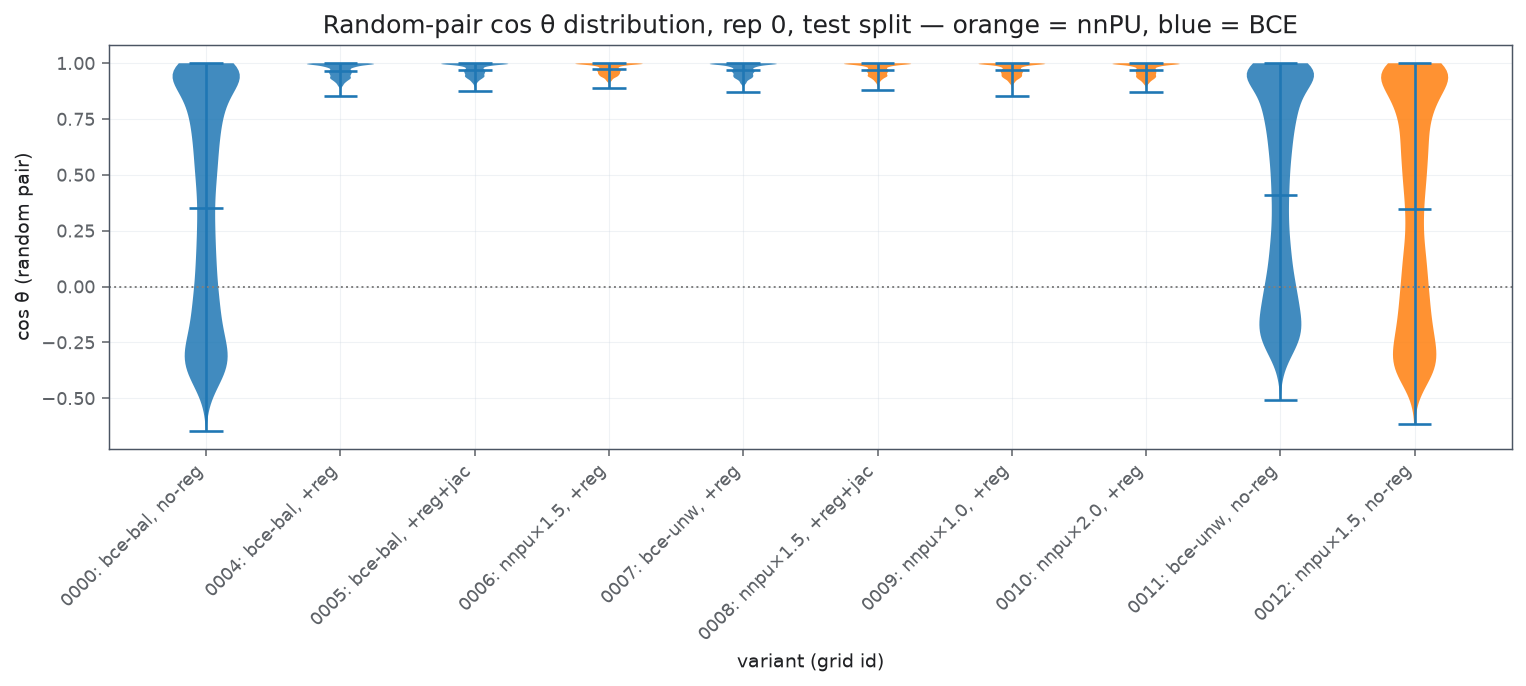

In [7]:
import matplotlib.pyplot as plt

variant_order = list(VARIANT_SPECS)
variant_colors = ["tab:orange" if variant in NNPU_VARIANTS else "tab:blue" for variant in variant_order]

figure, axis = plt.subplots(figsize=(0.9 * len(variant_order) + 2, 5.0), dpi=theme.figure_dpi)
parts = axis.violinplot([cos_theta_samples_by_variant[variant] for variant in variant_order], showmeans=True, showextrema=True)
for body, color in zip(parts["bodies"], variant_colors):
    body.set_facecolor(color)
    body.set_alpha(theme.primary_alpha)
axis.axhline(0.0, color="grey", linestyle=":", linewidth=1)
axis.set_xticks(range(1, len(variant_order) + 1))
axis.set_xticklabels([VARIANT_SHORT_LABELS[variant] for variant in variant_order], rotation=45, ha="right")
axis.set(ylabel="cos θ (random pair)", xlabel="variant (grid id)",
         title="Random-pair cos θ distribution, rep 0, test split — orange = nnPU, blue = BCE")
axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.tight_layout()

## RSA: does nnPU's correlation with label-Jaccard fall below BCE's? (rep 0 vs. all-5-rep check)

### Methodology
#### Theoretical
- The task spec's stated hypothesis: nnPU's non-negative correction should change
  how strongly latent geometry tracks the molecule labels, expected to show up as a
  lower RSA-Spearman correlation for `nnpu`-family variants vs. `bce`-family ones.
  Checked both pooled by head family (rep 0) and per-variant across all 5
  repetitions, since a pooled comparison can hide a confound that a per-variant
  breakdown reveals.

#### Implementation
- `geometry.rsa_spearman(u, labels, rng, pair_count)` per `(variant, repetition)`,
  aggregated two ways: `groupby("head_family")` (bce vs. nnpu, pooled across
  variants and repetitions) and `groupby("variant")` (per-variant mean/std across
  the 5 repetitions).

### Notes
- Pooled by head family: `bce` mean 0.661 (std 0.028), `nnpu` mean 0.656 (std
  0.025) — no meaningful difference, contradicting neither direction clearly.
- Per-variant breakdown shows the real pattern: `0000`/`0011`/`0012` (no
  `+contractive`) sit at 0.68-0.69 regardless of `bce` or `nnpu`; `0004`-`0010`
  (with `+contractive`) sit at 0.645-0.651, again regardless of `bce` or `nnpu`.
  `0012` (`nnpu`, no contractive) matches `0000`/`0011` (`bce`, no contractive)
  almost exactly; `0006`/`0008`/`0009`/`0010` (`nnpu`, with contractive) match
  `0004`/`0005`/`0007` (`bce`, with contractive) almost exactly. **RSA tracks
  `+contractive` presence, not the BCE/nnPU zero-interpretation choice at all** —
  the pooled-by-family comparison happened to wash this out because both families
  mix contractive and non-contractive members in roughly equal measure. The task
  spec's specific prediction is not supported by this data.


In [8]:
rsa_all_reps_rows = []
for variant, (campaign_id, grid_id) in VARIANT_SPECS.items():
    labels = labels_by_campaign[campaign_id]
    for repetition in REPETITIONS:
        u = u_by_variant_repetition[(variant, repetition)]
        rsa = geometry.rsa_spearman(u, labels, rsa_rng, pair_count=min(PAIR_COUNT, u.shape[0] * (u.shape[0] - 1)))
        rsa_all_reps_rows.append({"variant": variant, "repetition": repetition, "head_family": "nnpu" if variant in NNPU_VARIANTS else "bce", "rsa_spearman_r": rsa["spearman_r"]})

rsa_all_reps_frame = pd.DataFrame(rsa_all_reps_rows)
rsa_by_family = rsa_all_reps_frame.groupby("head_family")["rsa_spearman_r"].agg(["mean", "std", "min", "max"])
print("RSA by head family (bce vs nnpu), pooled across all their variants and repetitions:")
print(rsa_by_family)
rsa_all_reps_frame.groupby("variant")["rsa_spearman_r"].agg(["mean", "std"])

RSA by head family (bce vs nnpu), pooled across all their variants and repetitions:
                 mean       std       min       max
head_family                                        
bce          0.660935  0.027896  0.611589  0.713863
nnpu         0.655740  0.024607  0.615409  0.726002


,mean,std
variant,,
0000,0.680819,0.026681
0004,0.647655,0.024170
0005,0.648245,0.023187
0006,0.650826,0.023379
0007,0.644795,0.030016
0008,0.646044,0.022796
0009,0.649048,0.018621
0010,0.646826,0.014720
0011,0.683162,0.008674


## Pairwise geometry: full matrix, `0004` singled out as reference

### Methodology
#### Theoretical
- The single-model statistics above establish that variance/structure differs by
  variant, but not whether any two variants' latents are actually *the same shape*
  reorganized, or genuinely different shapes. Procrustes distance and linear CKA
  answer that directly, computed for every pair among the 10 variants (all 45
  pairs, 5 repetitions each) and checked against `part_9`'s seed-to-seed null for
  the same metrics.

#### Implementation
- `geometry.procrustes_distance` and `geometry.linear_cka` for
  `itertools.combinations(VARIANT_SPECS, 2)` (45 pairs), each across the 5
  repetition pairs, row-aligned on the same test pixels. `null_mean_for(variant,
  metric)` reads the corresponding seed-to-seed null mean from
  `part_9`'s `seed_null_distribution.csv`; `signal_over_null = observed / max(null
  means of the two variants)`. `0004` is highlighted as a fixed reference column
  since it anchors the `k`NN-overlap/trustworthiness/continuity section below too.

### Notes
- Confirms the same two-cluster split as the single-model statistics: distances
  from `0004` to the other `+contractive` variants stay small and mostly within
  their seed-noise null, while distances to `{0000, 0011, 0012}` are large and
  clear the null by a wide margin (see the closing notes for the full picture,
  point 1).
- Within the contractive cluster itself, every comparison against `0004` (the six
  variants `0005`-`0010`) still clears its own null (ratios 1.8-2.5) — unlike the
  original 4-objective `part_7`, where within-cluster pairs did not survive. At
  this larger 10-variant family, head loss / prior / Jaccard-weighting choice does
  leave a real, modest geometric mark on top of the dominant contractive-vs-not
  split.


In [9]:
def null_mean_for(variant: str, metric: str) -> float:
    rows = SEED_NULL_FRAME[(SEED_NULL_FRAME["variant"] == variant) & (SEED_NULL_FRAME["metryka"] == metric)]
    if rows.empty:
        return float("nan")
    per_rep = rows.groupby("repetition")["wartość"].first().to_numpy()
    diffs = [abs(a - b) for a, b in combinations(per_rep, 2)]
    return float(np.mean(diffs)) if diffs else float("nan")


all_pairs = list(combinations(VARIANT_SPECS, 2))
pairwise_rows = []
for left, right in all_pairs:
    for repetition in REPETITIONS:
        u_left = u_by_variant_repetition[(left, repetition)]
        u_right = u_by_variant_repetition[(right, repetition)]
        knn_k = min(KNN_K, u_left.shape[0] - 1)
        pairwise_rows.append({
            "left": left, "right": right, "repetition": repetition,
            "procrustes_distance": geometry.procrustes_distance(u_left, u_right),
            "linear_cka": geometry.linear_cka(u_left, u_right),
        })

pairwise_frame = pd.DataFrame(pairwise_rows)
pairwise_summary = pairwise_frame.groupby(["left", "right"])[["procrustes_distance", "linear_cka"]].mean().reset_index()
pairwise_summary["larger_null"] = pairwise_summary.apply(lambda row: max(null_mean_for(row["left"], "procrustes_distance"), null_mean_for(row["right"], "procrustes_distance")), axis=1)
pairwise_summary["signal_over_null"] = pairwise_summary["procrustes_distance"] / pairwise_summary["larger_null"]

print(f"vs. reference variant {REFERENCE_VARIANT}:")
vs_reference = pairwise_summary[(pairwise_summary["left"] == REFERENCE_VARIANT) | (pairwise_summary["right"] == REFERENCE_VARIANT)].copy()
vs_reference["other"] = vs_reference.apply(lambda row: row["right"] if row["left"] == REFERENCE_VARIANT else row["left"], axis=1)
vs_reference = vs_reference.sort_values("other")[["other", "procrustes_distance", "linear_cka", "larger_null", "signal_over_null"]]
vs_reference

vs. reference variant 0004:


,other,procrustes_distance,linear_cka,larger_null,signal_over_null
0,0000,0.285281,0.960704,0.068952,4.137401
9,0005,0.053964,0.998545,0.025890,2.084389
10,0006,0.058634,0.998377,0.030562,1.918551
11,0007,0.057322,0.998709,0.031362,1.827768
12,0008,0.064457,0.998107,0.025890,2.489672
13,0009,0.049232,0.999013,0.025890,1.901584
14,0010,0.059494,0.998128,0.025890,2.297957
15,0011,0.269462,0.966688,0.029365,9.176214
16,0012,0.268434,0.964916,0.031119,8.626153


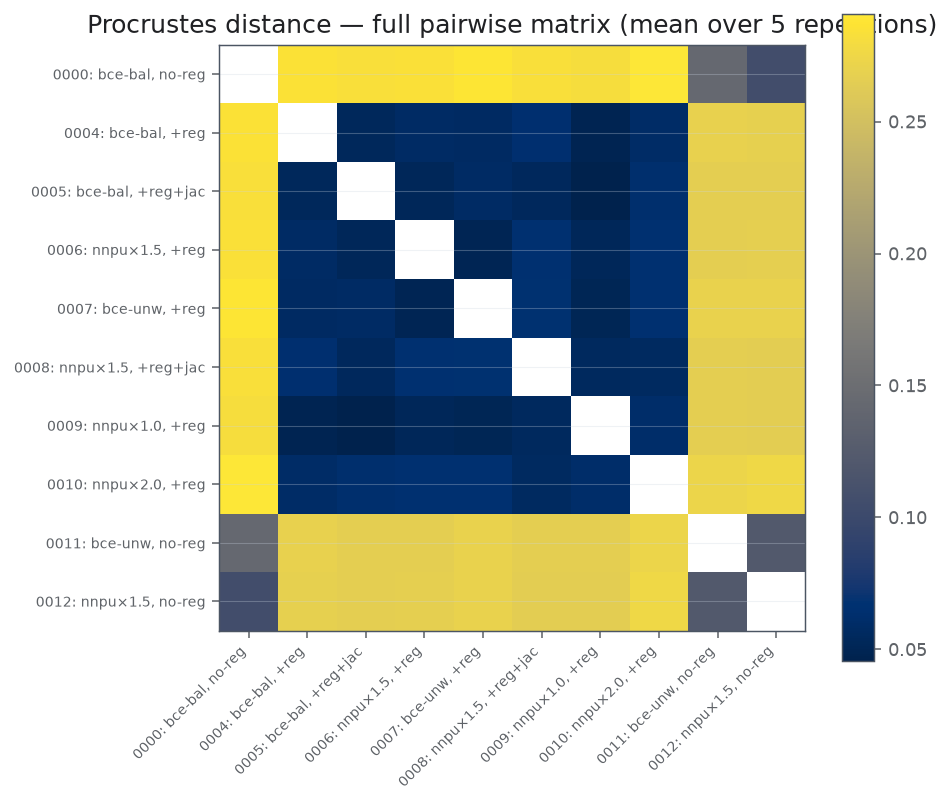

In [10]:
variant_order = list(VARIANT_SPECS)
matrix = pd.DataFrame(np.nan, index=variant_order, columns=variant_order)
for _, row in pairwise_summary.iterrows():
    matrix.loc[row["left"], row["right"]] = row["procrustes_distance"]
    matrix.loc[row["right"], row["left"]] = row["procrustes_distance"]

figure, ax = plt.subplots(figsize=(7.0, 6.0), dpi=theme.figure_dpi)
image = ax.imshow(matrix.to_numpy(dtype=float), cmap=theme.image_colormap)
short_labels = [VARIANT_SHORT_LABELS[variant] for variant in variant_order]
ax.set_xticks(range(len(variant_order))); ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(len(variant_order))); ax.set_yticklabels(short_labels, fontsize=7)
ax.set_title("Procrustes distance — full pairwise matrix (mean over 5 repetitions)")
figure.colorbar(image, ax=ax)
figure.tight_layout()

## `k`NN-overlap, trustworthiness, continuity vs. `0004`

### Methodology
#### Theoretical
- Complements the global Procrustes/CKA comparison with a local-neighborhood read:
  do the same pixels have the same nearest neighbors across variants, and is the
  overall rank-order of distances preserved even where local neighborhoods
  reshuffle? Both checked against `0004` as the fixed reference, same as the
  pairwise-geometry section above.

#### Implementation
- `geometry.knn_overlap(u_a, u_0004, k=10)` and
  `geometry.trustworthiness_continuity(u_0004, u_a, n_neighbors=10)` per variant,
  across the 5 repetitions; a random-baseline `k`NN-overlap (`k/N`) is printed for
  scale. The violin+scatter plot below shows the actual 5 per-repetition values per
  variant for all three metrics, rather than only the mean/std table above.

### Notes
- Random-baseline `k`NN-overlap: ~0.0025. `knn_overlap_vs_0004`: ~0.48 (no
  `+contractive`) vs. ~0.81-0.83 (`+contractive` present) — both far above the
  random baseline, confirming a large shared structure everywhere, with the
  cluster split as a real, secondary effect on top of it, not the whole story.
- `trustworthiness`/`continuity` vs. `0004`: ~0.9946-0.9948 (no contractive) vs.
  ~0.9995-0.9997 (contractive) — same split again, now confirmed identically
  across `part_3` (original 2-objective), `part_7` (4-objective), `part_9`
  (10-variant nulls), and this notebook (10-variant signal) — the single most
  robust finding in the whole latent-geometry side of this project.


In [11]:
neighborhood_rows = []
for variant in VARIANT_SPECS:
    if variant == REFERENCE_VARIANT:
        continue
    for repetition in REPETITIONS:
        u_reference = u_by_variant_repetition[(REFERENCE_VARIANT, repetition)]
        u_other = u_by_variant_repetition[(variant, repetition)]
        knn_k = min(KNN_K, u_reference.shape[0] - 1)
        tc = geometry.trustworthiness_continuity(u_reference, u_other, n_neighbors=knn_k)
        neighborhood_rows.append({
            "variant": variant, "repetition": repetition,
            "knn_overlap_vs_0004": geometry.knn_overlap(u_reference, u_other, k=knn_k),
            "trustworthiness_vs_0004": tc["trustworthiness"], "continuity_vs_0004": tc["continuity"],
        })

neighborhood_frame = pd.DataFrame(neighborhood_rows)
random_baseline_knn = KNN_K / len(test_ids)
print(f"random-baseline knn_overlap (k/N): {random_baseline_knn:.5f}")
neighborhood_frame.groupby("variant")[["knn_overlap_vs_0004", "trustworthiness_vs_0004", "continuity_vs_0004"]].agg(["mean", "std"])

random-baseline knn_overlap (k/N): 0.00249


knn_overlap_vs_0004           trustworthiness_vs_0004            \
                       mean       std                    mean       std   
variant                                                                   
0000               0.481690  0.020966                0.994819  0.001267   
0005               0.832120  0.018493                0.999667  0.000105   
0006               0.814457  0.013841                0.999513  0.000152   
0007               0.826179  0.021280                0.999591  0.000206   
0008               0.815521  0.022098                0.999550  0.000220   
0009               0.830510  0.023978                0.999666  0.000140   
0010               0.818131  0.037938                0.999614  0.000208   
0011               0.483097  0.016924                0.994975  0.001104   
0012               0.485409  0.010209                0.994824  0.000957   

        continuity_vs_0004            
                      mean       std  
variant                               
0000              0.994525  0.001200  
0005              0.999691  0.000063  
0006              0.999588  0.000107  
0007              0.999634  0.000180  
0008              0.999568  0.000183  
0009              0.999705  0.000102  
0010              0.999626  0.000200  
0011              0.994668  0.001412  
0012              0.994600  0.001388

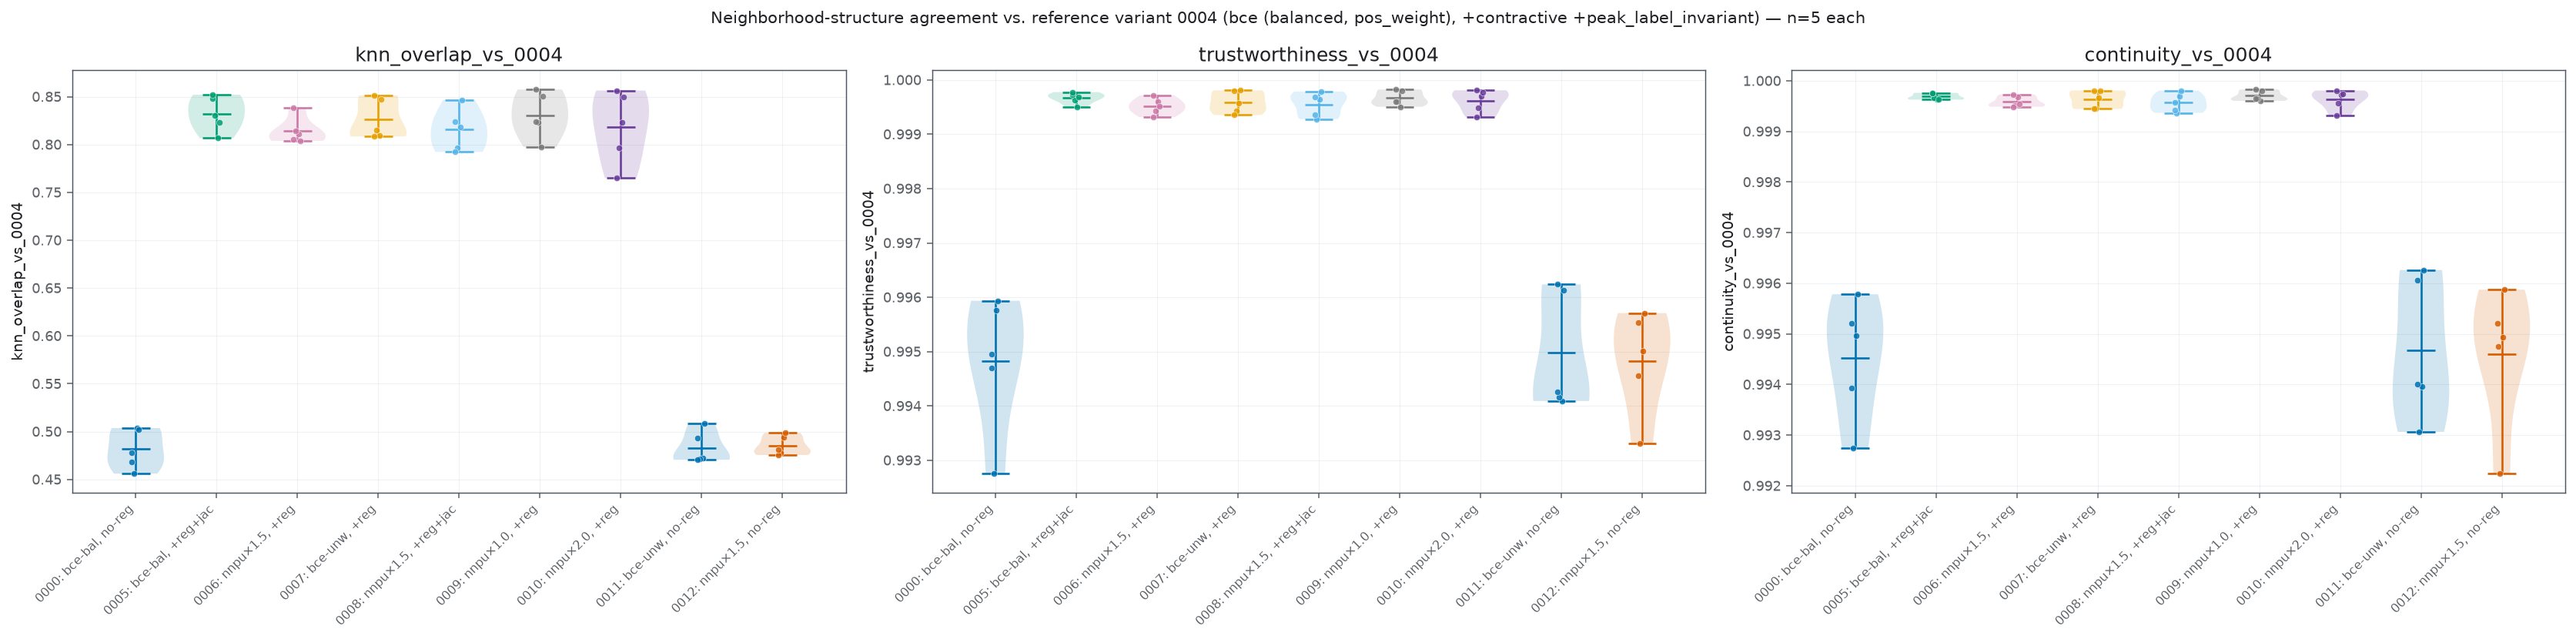

In [12]:
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

neighborhood_metric_names = ["knn_overlap_vs_0004", "trustworthiness_vs_0004", "continuity_vs_0004"]
other_variants = [variant for variant in VARIANT_SPECS if variant != REFERENCE_VARIANT]
figure, axes = plt.subplots(1, len(neighborhood_metric_names), figsize=(24.0, 6.0), dpi=theme.figure_dpi)
for axis, metric_name in zip(axes, neighborhood_metric_names):
    for index, variant in enumerate(other_variants):
        values = neighborhood_frame.loc[neighborhood_frame["variant"] == variant, metric_name].to_numpy()
        plot_violin_with_points(values, position=index, ax=axis, width=0.7, color=theme.color_for_model(variant, index))
    axis.set_xticks(range(len(other_variants)))
    axis.set_xticklabels([VARIANT_SHORT_LABELS[variant] for variant in other_variants], rotation=45, ha="right", fontsize=8)
    axis.set(ylabel=metric_name, title=metric_name)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
figure.suptitle(f"Neighborhood-structure agreement vs. reference variant {REFERENCE_VARIANT} ({VARIANT_DESCRIPTIONS[REFERENCE_VARIANT]}) — n=5 each", fontsize=11)
figure.tight_layout()

## Gradient contribution: reconstruction vs. classification pressure on `z`

### Methodology
#### Theoretical
- The stated loss weights are $\lambda_{\text{rec}}=1.0$,
  $\lambda_{\text{cls}}=0.2$ (`../report/methodology.md` §4-5), which would suggest
  reconstruction dominates the gradient signal reaching `z` roughly 5:1. This checks
  whether that is actually true at a converged checkpoint, or whether the
  *effective* gradient magnitude tells a different story once each loss's own scale
  (not just its stated weight) is accounted for.

#### Implementation
- `gradient_contribution(model, spectra, targets, mask, is_nnpu)`: computes
  `‖λ_rec·∂L_rec/∂z‖` and `‖λ_cls·∂L_cls/∂z‖` via `torch.autograd.grad(...,
  retain_graph=True)` on one 128-pixel batch per variant, at the model's final,
  converged checkpoint. `L_cls` for `nnpu` variants uses a simplified surrogate —
  softplus on labelled-positive pixels only, not the full non-negative-corrected
  risk — sufficient for a magnitude comparison, not a faithful reproduction of the
  exact training gradient. `cls_share = cls_grad_norm / (rec_grad_norm +
  cls_grad_norm)`.

### Notes
- `cls_share` is **≥0.9999 for every single variant** — `rec_grad_norm` sits at
  ~2-6e-8, `cls_grad_norm` at ~0.0002-0.005, four to five orders of magnitude
  larger. The stated loss weights suggest reconstruction should dominate 5:1; the
  actual gradient landscape on `z` at these converged checkpoints says the opposite
  by a huge margin. There is something real here — the loss-weight ratio is not a
  reliable guide to which term actually shapes `z`.
- Two scope caveats: this is measured at the final, converged checkpoint on one
  128-pixel batch, not accumulated over training, so it describes the *local*
  gradient geometry now, not the training trajectory that produced it; and (as
  noted above) the `nnpu` gradient uses a simplified classification-loss surrogate.


In [13]:
import torch.nn.functional as F

LAMBDA_REC = 1.0
LAMBDA_CLS = 0.2
GRADIENT_BATCH_SIZE = 128


def gradient_contribution(model, spectra: torch.Tensor, targets: torch.Tensor, mask: torch.Tensor, is_nnpu: bool) -> dict:
    device = next(model.parameters()).device
    spectra = spectra.to(device).requires_grad_(False)
    outputs = model(spectra)
    z = outputs["latent_space"]
    z.retain_grad()

    reconstruction_loss = F.mse_loss(outputs["reconstruction"], spectra)
    grad_rec = torch.autograd.grad(reconstruction_loss, z, retain_graph=True)[0]

    logits = outputs[f"head_{HEAD_NAME}"]
    target_device = targets.to(device)
    mask_device = mask.to(device)
    if is_nnpu:
        # Simplified surrogate matching the sign/shape of NNPUMultiLabelLoss's positive_risk
        # term only (softplus on labelled positives) — sufficient for a gradient-magnitude
        # comparison; the full non-negative-corrected risk is not needed here.
        labelled_positive = (target_device > 0.5) & mask_device
        classification_loss = F.softplus(-logits)[labelled_positive].mean() if labelled_positive.any() else logits.sum() * 0.0
    else:
        classification_loss = F.binary_cross_entropy_with_logits(logits[mask_device], target_device[mask_device])
    grad_cls = torch.autograd.grad(classification_loss, z, retain_graph=False)[0]

    rec_norm = float((LAMBDA_REC * grad_rec).norm(dim=1).mean())
    cls_norm = float((LAMBDA_CLS * grad_cls).norm(dim=1).mean())
    return {"rec_grad_norm": rec_norm, "cls_grad_norm": cls_norm, "cls_share": cls_norm / (rec_norm + cls_norm)}


gradient_rows = []
for variant, (campaign_id, grid_id) in VARIANT_SPECS.items():
    labels = labels_by_campaign[campaign_id]
    for repetition in REPETITIONS:
        model_name = f"{campaign_id}__{grid_id}__rep_0{repetition}"
        model = wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)
        model.eval()
        device = next(model.parameters()).device
        partitions = wrapper.active_dataset.create_partitions()
        index_by_id = {sid: index for index, sid in enumerate(partitions.manifest.assignments["test"])}
        sample_ids = test_ids[:GRADIENT_BATCH_SIZE]
        ordered_indices = [index_by_id[sid] for sid in sample_ids]
        items = [partitions.test[index] for index in ordered_indices]
        spectra = torch.stack([item[1] for item in items]).float()
        targets = torch.stack([item[2][TARGET_FIELD] for item in items]).float()
        mask = torch.stack([item[3][TARGET_FIELD] for item in items]).bool()
        result = gradient_contribution(model, spectra, targets, mask, is_nnpu=(variant in NNPU_VARIANTS))
        gradient_rows.append({"variant": variant, "repetition": repetition, **result})
    print(f"{variant}: gradient contribution computed")

gradient_frame = pd.DataFrame(gradient_rows)
gradient_frame.groupby("variant")[["rec_grad_norm", "cls_grad_norm", "cls_share"]].agg(["mean", "std"])

2026-08-28 15:28:13,825 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-28 15:28:13,825 | INFO     | msi_autoencoder_wrapper.models.model_loader:68 | Reconstructing loaded model family 'autoencoder'.


2026-08-28 15:28:13,826 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:173 | Initializing multi-component sub-graph resolution phase for model family: autoencoder


2026-08-28 15:28:13,826 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='encoder' using Strategy='CNNEncoder'.


2026-08-28 15:28:13,831 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='decoder' using Strategy='CNNDecoder'.


...

2026-08-28 15:28:22,148 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-08-28 15:28:22,151 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-08-28 15:28:22,155 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


0012: gradient contribution computed


rec_grad_norm               cls_grad_norm           cls_share  \
                 mean           std          mean       std      mean   
variant                                                                 
0000     2.199682e-08  1.524827e-08      0.000183  0.000028  0.999876   
0004     5.060332e-08  1.871351e-08      0.000444  0.000074  0.999883   
0005     5.438719e-08  2.106821e-08      0.000420  0.000069  0.999867   
0006     5.734101e-08  2.468906e-08      0.003749  0.000506  0.999985   
0007     5.247206e-08  2.000924e-08      0.000718  0.000085  0.999928   
0008     6.049903e-08  2.651828e-08      0.003822  0.000621  0.999984   
0009     5.217075e-08  1.779567e-08      0.004936  0.000389  0.999989   
0010     5.503651e-08  2.807315e-08      0.002329  0.000644  0.999976   
0011     1.735749e-08  7.334918e-09      0.000321  0.000047  0.999943   
0012     1.856891e-08  1.113876e-08      0.000687  0.000121  0.999973   

                   
              std  
variant            
0000     0.000083  
0004     0.000049  
0005     0.000056  
0006     0.000006  
0007     0.000025  
0008     0.000007  
0009     0.000003  
0010     0.000012  
0011     0.000032  
0012     0.000017

## $\lVert\gamma\rVert$ and $\kappa=\gamma_{\max}/\gamma_{\min}$ — `0006` vs. `0004`

### Methodology
#### Theoretical
- Checks whether the encoder's `LayerNorm` scale parameter $\gamma$ itself differs
  between an nnPU variant (`0006`) and its BCE counterpart (`0004`), which share
  the same contractive penalty and architecture and differ only in head loss — a
  control expected to show *no* difference, since $\gamma$ is a property of the
  encoder body, not the head.

#### Implementation
- $\lVert\gamma\rVert$ (L2 norm) and $\kappa=\gamma_{\max}/\gamma_{\min}$ computed
  directly from each model's saved encoder `LayerNorm.weight`, across the 5
  repetitions of `0004` and `0006`.

### Notes
- `0004`: $\lVert\gamma\rVert=2.739$ (std 0.038), $\kappa=1.233$ (std 0.078).
  `0006`: $\lVert\gamma\rVert=2.732$ (std 0.038), $\kappa=1.230$ (std 0.074) —
  essentially identical, exactly as expected since both share the same contractive
  penalty. Both $\kappa$ values are also consistent with the earlier
  $\kappa\approx 1$ finding for the original predictive-campaign models
  (methodology Q&A) — this trained $\gamma$'s low relative spread is a general
  property of this architecture, not specific to any one ablation.


In [14]:
gamma_rows = []
for variant in ("0004", "0006"):
    for repetition in REPETITIONS:
        gamma = gamma_by_variant_repetition[(variant, repetition)]
        gamma_rows.append({
            "variant": variant, "repetition": repetition,
            "gamma_norm": float(np.linalg.norm(gamma)),
            "gamma_min": float(gamma.min()), "gamma_max": float(gamma.max()),
            "kappa": float(gamma.max() / gamma.min()),
        })
gamma_frame = pd.DataFrame(gamma_rows)
gamma_frame.groupby("variant")[["gamma_norm", "kappa"]].agg(["mean", "std"])

gamma_norm               kappa          
              mean       std      mean       std
variant                                         
0004      2.739410  0.038061  1.232545  0.078213
0006      2.731699  0.037652  1.229839  0.074293

In [15]:
output_rows = []
for _, row in single_model_frame.iterrows():
    campaign_id = VARIANT_SPECS[row["variant"]][0]
    for metric_name in ("sd_cos_theta", "effective_rank", "participation_ratio", "two_nn_intrinsic_dimension", "rsa_spearman_r"):
        output_rows.append({"campaign": campaign_id, "variant": row["variant"], "repetition": 0, "metryka": metric_name, "wartość": row[metric_name]})
for _, row in vs_reference.iterrows():
    campaign_id = VARIANT_SPECS[row["other"]][0]
    for metric_name in ("procrustes_distance", "linear_cka", "signal_over_null"):
        output_rows.append({"campaign": campaign_id, "variant": row["other"], "repetition": "vs_0004_mean5rep", "metryka": metric_name, "wartość": row[metric_name]})
for _, row in neighborhood_frame.iterrows():
    campaign_id = VARIANT_SPECS[row["variant"]][0]
    for metric_name in ("knn_overlap_vs_0004", "trustworthiness_vs_0004", "continuity_vs_0004"):
        output_rows.append({"campaign": campaign_id, "variant": row["variant"], "repetition": row["repetition"], "metryka": metric_name, "wartość": row[metric_name]})
for _, row in gradient_frame.iterrows():
    campaign_id = VARIANT_SPECS[row["variant"]][0]
    for metric_name in ("rec_grad_norm", "cls_grad_norm", "cls_share"):
        output_rows.append({"campaign": campaign_id, "variant": row["variant"], "repetition": row["repetition"], "metryka": metric_name, "wartość": row[metric_name]})
for _, row in gamma_frame.iterrows():
    campaign_id = VARIANT_SPECS[row["variant"]][0]
    for metric_name in ("gamma_norm", "kappa"):
        output_rows.append({"campaign": campaign_id, "variant": row["variant"], "repetition": row["repetition"], "metryka": metric_name, "wartość": row[metric_name]})

latent_geometry_frame = pd.DataFrame(output_rows)
latent_geometry_frame.to_csv(RESULTS_DIRECTORY / "latent_geometry.csv", index=False)
print(f"wrote {RESULTS_DIRECTORY / 'latent_geometry.csv'} ({len(latent_geometry_frame)} rows)")

wrote assets/experiments/08_26/23_08_26_architecture_predictive/nnpu_followup/results/latent_geometry.csv (382 rows)


## Notes for the next pass

### 1. The contractive-driven two-cluster split reproduces exactly, on every metric

`sd_cos_theta`: `{0000, 0011, 0012}` (no `+contractive`) sit at 0.46-0.51; every
other variant (`+contractive` present) sits at 0.023-0.030. `knn_overlap_vs_0004`:
~0.48 (no contractive) vs. ~0.81-0.83 (contractive) — both far above the random
baseline (0.0025), confirming a large shared structure everywhere, with the cluster
split as a real, secondary effect on top of it. `trustworthiness`/`continuity`
vs. `0004`: ~0.9946-0.9948 (no contractive) vs. ~0.9995-0.9997 (contractive) — same
split again. This is now confirmed across `part_3`(original 2-objective)/`part_7`
(4-objective)/`part_9`(10-variant nulls)/this notebook (10-variant signal) — it is
the single most robust finding in the whole latent-geometry side of this project.

### 2. The RSA prediction ("should fall for nnPU") is not confirmed as stated —
the real driver is the same contractive split, not bce/nnpu

Pooled by head family: `bce` mean 0.661 (std 0.028), `nnpu` mean 0.656 (std 0.025) —
no meaningful difference, contradicting neither direction clearly. But looking at
individual variants makes the real pattern obvious: `0000`/`0011`/`0012` (no
`+contractive`) sit at 0.68-0.69 regardless of `bce` or `nnpu`; `0004`-`0010` (with
`+contractive`) sit at 0.645-0.651, again regardless of `bce` or `nnpu`. `0012`
(`nnpu`, no contractive) matches `0000`/`0011` (`bce`, no contractive) almost
exactly; `0006`/`0008`/`0009`/`0010` (`nnpu`, with contractive) match
`0004`/`0005`/`0007` (`bce`, with contractive) almost exactly. **RSA tracks
`+contractive` presence, not the BCE/nnPU zero-interpretation choice at all** — the
pooled-by-family comparison happened to wash this out because both families mix
contractive and non-contractive members in roughly equal measure. The task spec's
specific prediction should be read as not supported by this data.

### 3. Within the contractive cluster, `0004`-vs-everything-else still survives the null

Every comparison against `0004` clears its null, including the six
*within-cluster* ones (`0005`-`0010`, ratios 1.8-2.5) — unlike the original
4-objective `part_7`, where within-cluster pairs (`bce` vs. `+peak_random`, etc.)
did *not* survive. So within this larger 10-variant family, the specific choice of
head loss / prior / Jaccard weighting *does* leave a real, modest geometric mark on
top of the dominant contractive-vs-not split — even though `part_13` found most of
these same differences do *not* translate into a detectable downstream AP/AUROC
effect (except `0007`'s anomaly). Geometry moves; the classification head mostly
doesn't notice.

### 4. Gradient contribution: classification dominates by 4-5 orders of magnitude,
despite lambda_rec=1.0 > lambda_cls=0.2

`cls_share` (share of the two losses' gradient magnitude landing on `z`) is
**>=0.9999 for every single variant** — `rec_grad_norm` sits at ~2-6e-8,
`cls_grad_norm` at ~0.0002-0.005, four to five orders of magnitude larger. The
stated loss weights ($\lambda_{\text{rec}}=1.0$ vs. $\lambda_{\text{cls}}=0.2$)
suggest reconstruction should dominate 5:1; the actual gradient landscape on `z` at
these converged checkpoints says the opposite by a huge margin. **There is
something real to look at here** — the loss-weight ratio is not a reliable guide to
which term actually shapes `z`. Two scope caveats: this is measured at the final,
converged checkpoint on one 128-pixel batch, not accumulated over training, so it
describes the *local* gradient geometry now, not the training trajectory that
produced it; and the `nnpu` gradient uses a simplified surrogate (the positive-risk
term's `softplus` only, not the full non-negative-corrected risk) — sufficient for
this magnitude comparison but not a faithful reproduction of the exact training
gradient.

### 5. `gamma_norm`/`kappa` for `0004` vs. `0006` — matches expectation exactly

`0004`: $\lVert\gamma\rVert=2.739$ (std 0.038), $\kappa=1.233$ (std 0.078). `0006`:
$\lVert\gamma\rVert=2.732$ (std 0.038), $\kappa=1.230$ (std 0.074) — essentially
identical, exactly as expected since both share the same contractive penalty. Both
$\kappa$ values are also consistent with the earlier $\kappa\approx 1$ finding for
the original predictive-campaign models (methodology Q&A) — this trained
$\gamma$'s low relative spread is a general property of this architecture, not
specific to any one ablation.